In [13]:
import sys, os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

sys.path.insert(0, '..')
from nlp.missing_detector import analyse, INTENT_REQUIRED_FIELDS, predict

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d', 'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e', 'ytick.color': '#8b949e',
    'text.color': '#c9d1d9', 'grid.color': '#21262d',
    'grid.linestyle': '--', 'grid.alpha': 0.5,
    'axes.titlesize': 12, 'axes.labelsize': 10,
    'font.family': 'monospace',
})
C = ['#58a6ff','#3fb950','#f78166','#d2a8ff','#ffa657']

ci = pd.read_csv('../data/final/cleaned_issues.csv')
rl = pd.read_csv('../data/final/final_rl_dataset.csv')

missing_cols = ['missing_version','missing_error','missing_platform',
                'missing_hardware','missing_count','completeness_score']

if not all(c in ci.columns for c in missing_cols):
    print('Missing flags not found. Run:')
    print('  python nlp/missing_detector.py')
else:
    data = analyse('../data/final/cleaned_issues.csv',
                   '../data/final/final_rl_dataset.csv')
    print('Missing detection complete.')
    print(f'  Issues: {len(ci)}')
    print(f'  Avg completeness score: {data["completeness_dist"]["mean"]:.3f}')
    print(f'  Fully complete tickets: {data["completeness_dist"]["pct_1"]:.1f}%')

Missing detection complete.
  Issues: 852
  Avg completeness score: 0.821
  Fully complete tickets: 71.5%


---
## 1. Missing Flag Rates

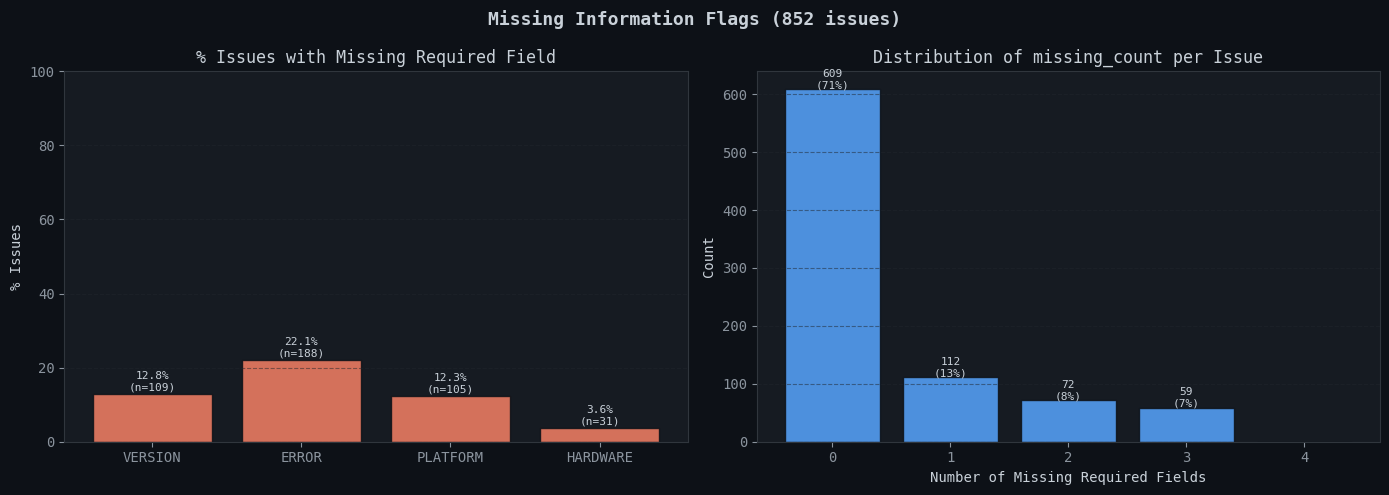

In [3]:
flag_cols   = ['missing_version','missing_error','missing_platform','missing_hardware']
flag_labels = ['VERSION','ERROR','PLATFORM','HARDWARE']
flag_rates  = [ci[c].mean()*100 for c in flag_cols]
flag_counts = [ci[c].sum() for c in flag_cols]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Missing Information Flags (852 issues)', fontweight='bold', fontsize=13)

# Flag rates
bars = axes[0].bar(flag_labels, flag_rates, color=C[2], alpha=0.85, edgecolor='#0d1117')
axes[0].set_title('% Issues with Missing Required Field')
axes[0].set_ylabel('% Issues')
axes[0].set_ylim(0, 100)
axes[0].grid(axis='y')
for bar, pct, cnt in zip(bars, flag_rates, flag_counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{pct:.1f}%\n(n={cnt})', ha='center', fontsize=8)

# Missing count distribution
mc_counts = [data['missing_count_dist'].get(i,0) for i in range(5)]
axes[1].bar(range(5), mc_counts, color=C[0], alpha=0.85, edgecolor='#0d1117')
axes[1].set_title('Distribution of missing_count per Issue')
axes[1].set_xlabel('Number of Missing Required Fields')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(5))
axes[1].grid(axis='y')
for i, v in enumerate(mc_counts):
    if v > 0:
        axes[1].text(i, v+1, f'{v}\n({v/len(ci)*100:.0f}%)', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

---
## 2. Completeness Score Distribution

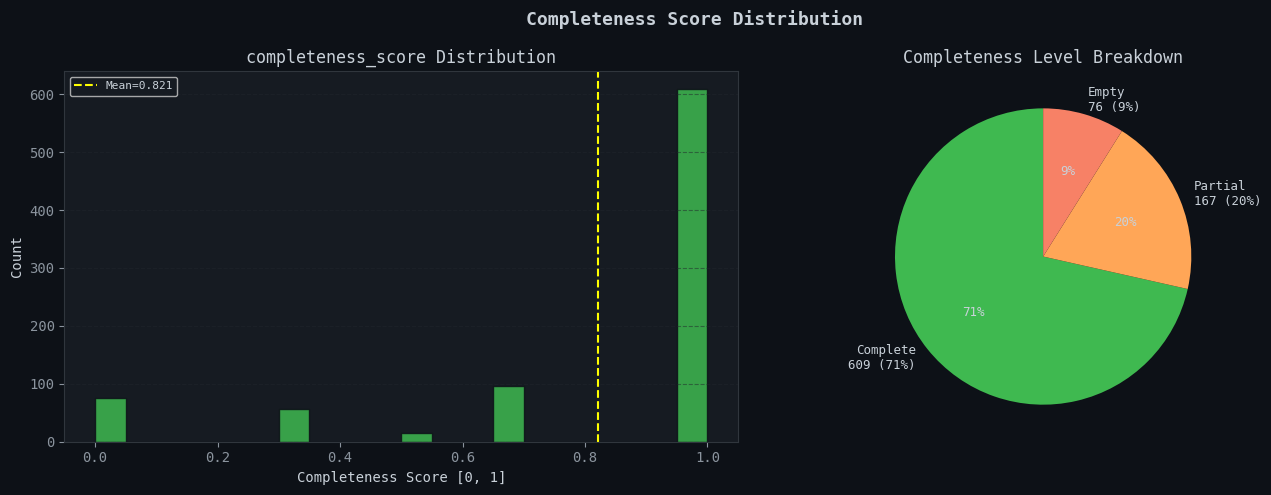

Mean completeness: 0.821
Fully complete:    609 (71.5%)
Partially complete:167 (19.6%)
Nothing present:   76 (8.9%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Completeness Score Distribution', fontweight='bold', fontsize=13)

# Histogram
axes[0].hist(ci['completeness_score'], bins=20, color=C[1],
             alpha=0.85, edgecolor='#0d1117')
axes[0].axvline(ci['completeness_score'].mean(), color='yellow',
                linestyle='--', label=f'Mean={ci["completeness_score"].mean():.3f}')
axes[0].set_title('completeness_score Distribution')
axes[0].set_xlabel('Completeness Score [0, 1]')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y')

# Pie chart of completeness levels
fully    = (ci['completeness_score'] == 1.0).sum()
partial  = ((ci['completeness_score'] > 0) & (ci['completeness_score'] < 1.0)).sum()
empty    = (ci['completeness_score'] == 0.0).sum()
sizes    = [fully, partial, empty]
labels   = [f'Complete\n{fully} ({fully/len(ci)*100:.0f}%)',
             f'Partial\n{partial} ({partial/len(ci)*100:.0f}%)',
             f'Empty\n{empty} ({empty/len(ci)*100:.0f}%)']
colors   = [C[1], C[4], C[2]]
axes[1].pie([s for s in sizes if s > 0],
            labels=[labels[i] for i, s in enumerate(sizes) if s > 0],
            colors=[colors[i] for i, s in enumerate(sizes) if s > 0],
            autopct='%1.0f%%', startangle=90,
            textprops={'fontsize': 9})
axes[1].set_title('Completeness Level Breakdown')

plt.tight_layout()
plt.show()

print(f'Mean completeness: {ci["completeness_score"].mean():.3f}')
print(f'Fully complete:    {fully} ({fully/len(ci)*100:.1f}%)')
print(f'Partially complete:{partial} ({partial/len(ci)*100:.1f}%)')
print(f'Nothing present:   {empty} ({empty/len(ci)*100:.1f}%)')

---
## 3. Completeness by Intent Group

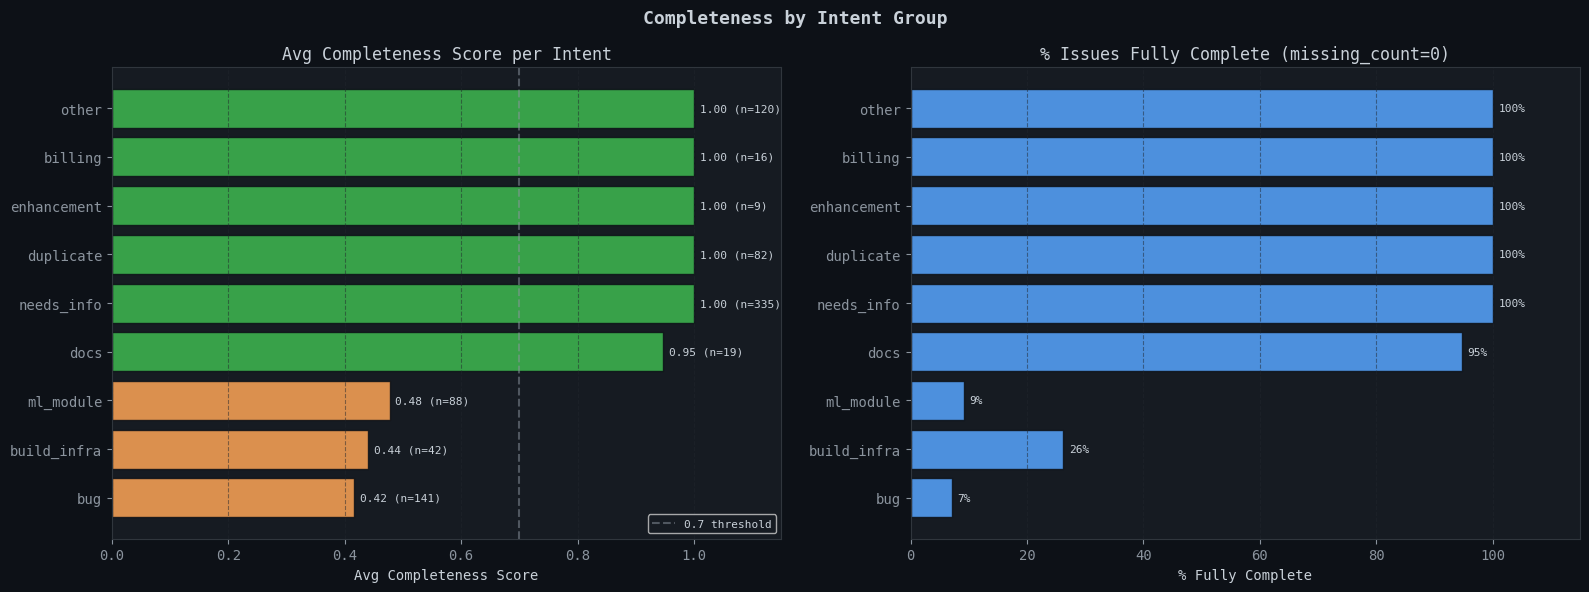

Required fields per intent:
  bug            : error_type, platform, version  (n=141)
  ml_module      : error_type, hardware, version  (n=88)
  build_infra    : platform, version  (n=42)
  docs           : version  (n=19)
  needs_info     : — (none)  (n=335)
  duplicate      : — (none)  (n=82)
  enhancement    : — (none)  (n=9)
  billing        : — (none)  (n=16)
  other          : — (none)  (n=120)


In [5]:
if 'intent_group' not in ci.columns:
    print('intent_group not found. Run confidence_estimator --mode generate first.')
else:
    intent_stats = data.get('intent_stats', {})
    intents = list(intent_stats.keys())
    avg_comp = [intent_stats[i]['avg_completeness'] for i in intents]
    pct_full = [intent_stats[i]['pct_complete'] for i in intents]
    ns       = [intent_stats[i]['n'] for i in intents]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Completeness by Intent Group', fontweight='bold', fontsize=13)

    # Sort by avg completeness
    order = np.argsort(avg_comp)
    intents_s  = [intents[i]  for i in order]
    avg_comp_s = [avg_comp[i] for i in order]
    pct_full_s = [pct_full[i] for i in order]
    ns_s       = [ns[i]       for i in order]

    # Average completeness score
    colors = [C[1] if v >= 0.7 else (C[4] if v >= 0.4 else C[2]) for v in avg_comp_s]
    bars = axes[0].barh(intents_s, avg_comp_s, color=colors, alpha=0.85, edgecolor='#0d1117')
    axes[0].axvline(0.7, color='#8b949e', linestyle='--', alpha=0.5, label='0.7 threshold')
    axes[0].set_title('Avg Completeness Score per Intent')
    axes[0].set_xlabel('Avg Completeness Score')
    axes[0].set_xlim(0, 1.15)
    axes[0].legend(fontsize=8)
    axes[0].grid(axis='x')
    for bar, v, n in zip(bars, avg_comp_s, ns_s):
        axes[0].text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                     f'{v:.2f} (n={n})', va='center', fontsize=8)

    # % Fully complete
    bars2 = axes[1].barh(intents_s, pct_full_s, color=C[0], alpha=0.85, edgecolor='#0d1117')
    axes[1].set_title('% Issues Fully Complete (missing_count=0)')
    axes[1].set_xlabel('% Fully Complete')
    axes[1].set_xlim(0, 115)
    axes[1].grid(axis='x')
    for bar, v in zip(bars2, pct_full_s):
        axes[1].text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
                     f'{v:.0f}%', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()

    print('Required fields per intent:')
    for intent, fields in INTENT_REQUIRED_FIELDS.items():
        req = ', '.join(sorted(fields)) if fields else '— (none)'
        stats = intent_stats.get(intent, {})
        n = stats.get('n', 0)
        print(f'  {intent:15s}: {req}  (n={n})')

---
## 4. Completeness vs Resolution Success

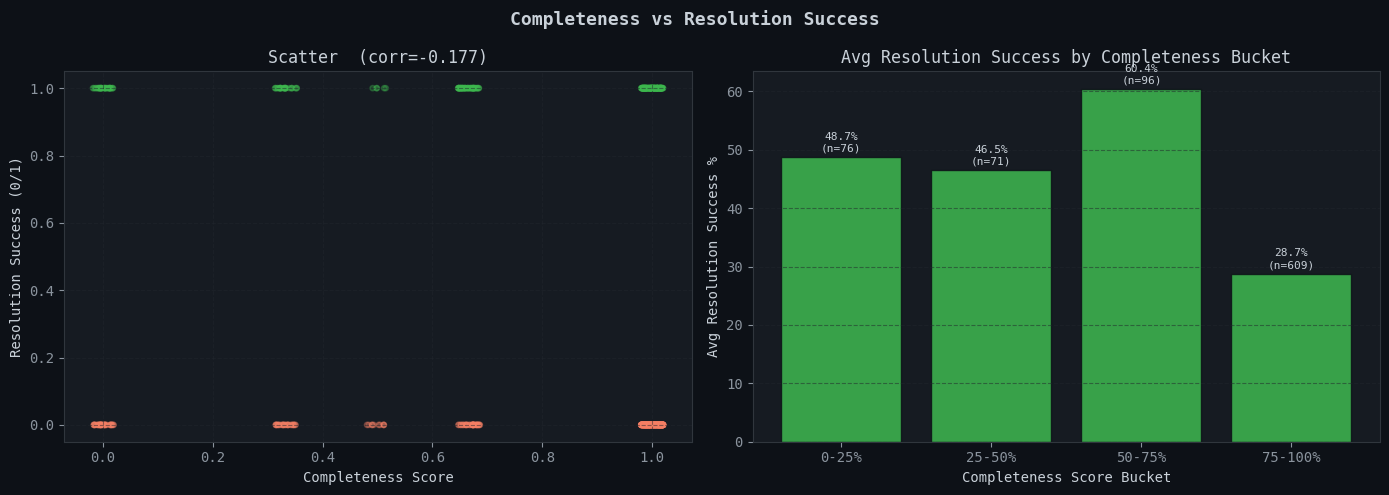

Correlation: completeness_score vs resolution_success = -0.1767
Positive correlation confirms complete tickets resolve more successfully.


In [6]:
if 'resolution_success' not in rl.columns:
    print('resolution_success not in RL dataset.')
else:
    merged = ci.merge(rl[['issue_number','resolution_success']], on='issue_number', how='left')
    corr   = merged['completeness_score'].corr(merged['resolution_success'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Completeness vs Resolution Success', fontweight='bold', fontsize=13)

    # Scatter
    jitter = np.random.uniform(-0.02, 0.02, len(merged))
    colors_scatter = [C[1] if v == 1 else C[2] for v in merged['resolution_success'].fillna(0)]
    axes[0].scatter(merged['completeness_score'] + jitter,
                    merged['resolution_success'].fillna(0),
                    alpha=0.3, s=15, c=colors_scatter)
    axes[0].set_title(f'Scatter  (corr={corr:.3f})')
    axes[0].set_xlabel('Completeness Score')
    axes[0].set_ylabel('Resolution Success (0/1)')
    axes[0].grid()

    # By bucket
    merged['bucket'] = pd.cut(
        merged['completeness_score'],
        bins=[0, 0.25, 0.5, 0.75, 1.01],
        labels=['0-25%','25-50%','50-75%','75-100%'],
        include_lowest=True
    )
    bucket_stats = merged.groupby('bucket', observed=True)['resolution_success'].agg(['mean','count'])
    axes[1].bar(bucket_stats.index.astype(str),
                bucket_stats['mean']*100,
                color=C[1], alpha=0.85, edgecolor='#0d1117')
    axes[1].set_title('Avg Resolution Success by Completeness Bucket')
    axes[1].set_xlabel('Completeness Score Bucket')
    axes[1].set_ylabel('Avg Resolution Success %')
    axes[1].grid(axis='y')
    for i, (idx, row) in enumerate(bucket_stats.iterrows()):
        axes[1].text(i, row['mean']*100+1,
                     f'{row["mean"]*100:.1f}%\n(n={int(row["count"])})',
                     ha='center', fontsize=8)

    plt.tight_layout()
    plt.show()
    print(f'Correlation: completeness_score vs resolution_success = {corr:.4f}')
    print('Positive correlation confirms complete tickets resolve more successfully.')

---
## 5. Live Demo

In [7]:
demo_cases = [
    # intent, has_version, has_error, has_platform, has_hardware, description
    ('bug',         1, 1, 1, 0, 'bug with version+error+platform (complete)'),
    ('bug',         1, 0, 0, 0, 'bug with only version (incomplete)'),
    ('bug',         0, 0, 0, 0, 'bug with nothing (very incomplete)'),
    ('ml_module',   1, 1, 0, 1, 'ml_module with version+error+hardware (complete)'),
    ('ml_module',   1, 0, 0, 0, 'ml_module missing error+hardware'),
    ('build_infra', 1, 0, 1, 0, 'build_infra with version+platform (complete)'),
    ('billing',     0, 0, 0, 0, 'billing with nothing (still complete)'),
    ('duplicate',   0, 0, 0, 0, 'duplicate with nothing (still complete)'),
    ('enhancement', 0, 0, 0, 0, 'enhancement with nothing (still complete)'),
]

print(f'{"Intent":<14} {"VER":>4} {"ERR":>4} {"PLT":>4} {"HW":>4}'
      f' {"Missing":>8} {"Score":>6}  Summary')
print('─' * 100)

for intent, v, e, p, h, desc in demo_cases:
    r = predict(intent, v, e, p, h)
    vstr = '✓' if v else '✗'
    estr = '✓' if e else '✗'
    pstr = '✓' if p else '✗'
    hstr = '✓' if h else '✗'
    print(f'{intent:<14} {vstr:>4} {estr:>4} {pstr:>4} {hstr:>4}'
          f' {r["missing_count"]:>8} {r["completeness_score"]:>6.2f}'
          f'  {r["summary"]}')

Intent          VER  ERR  PLT   HW  Missing  Score  Summary
────────────────────────────────────────────────────────────────────────────────────────────────────
bug               ✓    ✓    ✓    ✗        0   1.00  All required fields present (error_type, platform, version)
bug               ✓    ✗    ✗    ✗        2   0.33  Missing: error_type, platform (required for bug)
bug               ✗    ✗    ✗    ✗        3   0.00  Missing: version, error_type, platform (required for bug)
ml_module         ✓    ✓    ✗    ✓        0   1.00  All required fields present (error_type, hardware, version)
ml_module         ✓    ✗    ✗    ✗        2   0.33  Missing: error_type, hardware (required for ml_module)
build_infra       ✓    ✗    ✓    ✗        0   1.00  All required fields present (platform, version)
billing           ✗    ✗    ✗    ✗        0   1.00  Intent 'billing' requires no specific fields — complete by default
duplicate         ✗    ✗    ✗    ✗        0   1.00  Intent 'duplicate' require

---
## 7. Clarification Modeler — Dual-Trigger Policy

Needs clarification: 629/852 (73.8%)


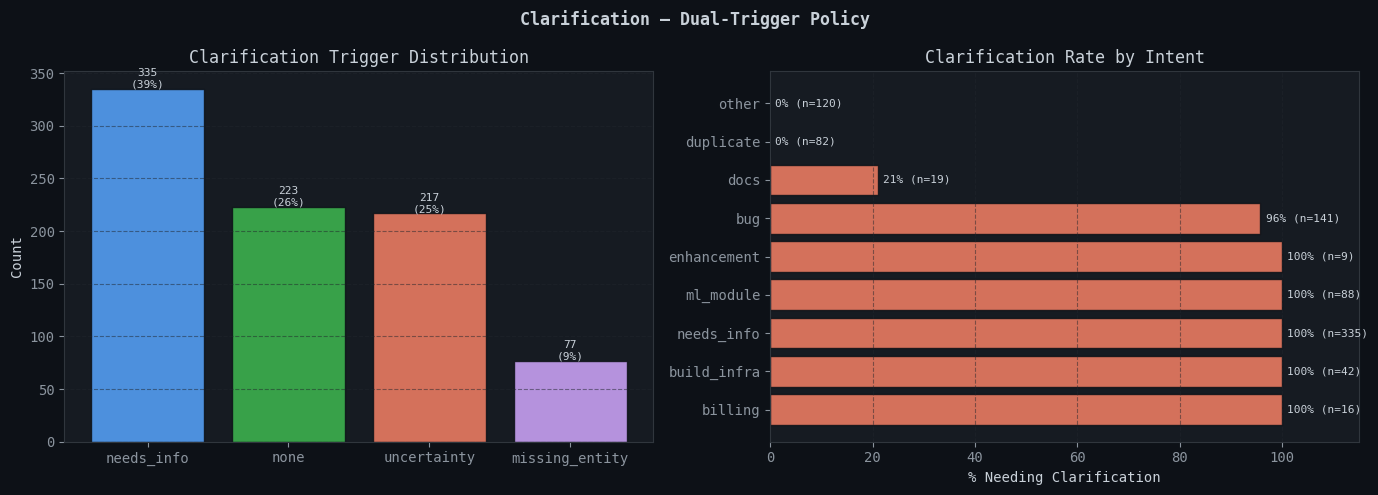

In [15]:
if 'needs_clarification' not in ci.columns:
    print('Run: python nlp/clarification_modeler.py')
else:
    needs = ci['needs_clarification'].sum()
    total = len(ci)
    print(f'Needs clarification: {needs}/{total} ({needs/total*100:.1f}%)')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Clarification — Dual-Trigger Policy', fontweight='bold')

    # Trigger distribution
    trig_counts = ci["clarification_trigger"].value_counts()
    axes[0].bar(trig_counts.index, trig_counts.values,
                color=C[:len(trig_counts)], alpha=0.85, edgecolor='#0d1117')
    axes[0].set_title('Clarification Trigger Distribution')
    axes[0].set_ylabel('Count')
    axes[0].grid(axis='y')
    for i, (idx, v) in enumerate(trig_counts.items()):
        axes[0].text(i, v+1, f'{v}\n({v/total*100:.0f}%)', ha='center', fontsize=8)

    # Rate by intent
    if 'intent_group' in ci.columns:
        ic = ci.groupby('intent_group')['needs_clarification'].agg(['mean','count'])
        ic = ic[ic['count'] >= 5].sort_values('mean', ascending=False)
        axes[1].barh(ic.index, ic['mean']*100,
                     color=C[2], alpha=0.85, edgecolor='#0d1117')
        axes[1].set_title('Clarification Rate by Intent')
        axes[1].set_xlabel('% Needing Clarification')
        axes[1].set_xlim(0, 115)
        axes[1].grid(axis='x')
        for i, (idx, row) in enumerate(ic.iterrows()):
            axes[1].text(row['mean']*100+1, i,
                         f'{row["mean"]*100:.0f}% (n={int(row["count"])})',
                         va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

---
## 8. Clarification Demo — All Scenarios

In [16]:
from nlp.clarification_modeler import predict as clar_predict

demos = [
    # intent, unc, mv, me, mp, mh, wc, description
    ('bug',        0, 0, 1, 1, 0, 80,  'confident bug + missing error+platform → entity'),
    ('bug',        0, 1, 0, 0, 0, 80,  'confident bug + only version missing → ask version'),
    ('bug',        1, 0, 0, 0, 0, 80,  'UNCERTAIN bug → generic semantic question'),
    ('ml_module',  0, 1, 1, 0, 1, 100, 'confident ml_module + missing error → ask error first'),
    ('ml_module',  1, 1, 1, 0, 1, 100, 'UNCERTAIN ml_module → generic question (not entity)'),
    ('needs_info', 0, 0, 0, 0, 0, 50,  'needs_info ALWAYS clarifies'),
    ('needs_info', 1, 0, 0, 0, 0, 50,  'needs_info ALWAYS clarifies (even uncertain)'),
    ('duplicate',  0, 0, 0, 0, 0, 50,  'duplicate → NEVER clarify, use RAG'),
    ('duplicate',  1, 0, 0, 0, 0, 50,  'duplicate uncertain → still never clarify'),
    ('other',      0, 0, 0, 0, 0, 50,  'other → NEVER clarify, escalate'),
    ('billing',    0, 0, 0, 0, 0, 60,  'confident billing → route directly, no clarify'),
    ('billing',    1, 0, 0, 0, 0, 60,  'UNCERTAIN billing → ask to confirm'),
    ('enhancement',0, 0, 0, 0, 0, 8,   'vague enhancement (8 words) → ask to elaborate'),
    ('enhancement',0, 0, 0, 0, 0, 30,  'clear enhancement (30 words) → route_product'),
    ('build_infra',0, 1, 0, 1, 0, 70,  'confident build_infra + missing version+platform'),
]

print(f'{"Intent":<14} {"Unc":>4} {"Need?":>6} {"Priority":>9} {"Trigger":<15} Question')
print('─'*110)
for intent, unc, mv, me, mp, mh, wc, desc in demos:
    r = clar_predict(intent, unc, mv, me, mp, mh, wc)
    need = 'YES' if r['needs_clarification'] else 'no'
    pri  = f'p={r["clarification_priority"]} ({r["clarification_type"]})'
    trig = r['clarification_trigger']
    q    = r['clarification_question'][:45] + '...' if len(r['clarification_question']) > 45 else r['clarification_question'] or '—'
    print(f'{intent:<14} {str(unc):>4} {need:>6} {pri:>9} {trig:<15} {q}')
    if desc:
        print(f'  ↑ {desc}')

Intent          Unc  Need?  Priority Trigger         Question
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
bug               0    YES p=3 (error_type) missing_entity  Could you share the exact error message or st...
  ↑ confident bug + missing error+platform → entity
bug               0    YES p=4 (version) missing_entity  What version of the software are you using? T...
  ↑ confident bug + only version missing → ask version
bug               1    YES p=1 (uncertainty) uncertainty     We are not entirely sure what type of issue t...
  ↑ UNCERTAIN bug → generic semantic question
ml_module         0    YES p=3 (error_type) missing_entity  What is the exact error message you are seein...
  ↑ confident ml_module + missing error → ask error first
ml_module         1    YES p=1 (uncertainty) uncertainty     Could you provide more context about the issu...
  ↑ UNCERTAIN ml_module → generic question (not entity)
needs_info      